# To be able to edit and use this Notebook:

0. Learn about how to use google colaboratory [video]()
1. in the file menu (top left), click ```open in playground```
3. still in the file menu, click ```save copy in drive```, to make your own personalized and editable copy of this file.
4. edit as you like. If something breaks irreparably, either:
  1. restart the ```Runtime```
  2. or go back to step 1.


# Dynamics of the Adaptive Exponential Integrate and Fire

In the last project we dove into the equations of the Hodgkin Huxley model of spike generation. That model is described by the temporal evolution of four state variables (quiz yourself: do you know which are the state variables of the HH?), and hence its dynamics are quite complex to analyze. 

In this project we will learn how to simulate and parameterize the **Adaptive Exponential Integrate and Fire model** (AdEx).  You will observe how the parameters of the AdEx model can lead it to produce a vast variety of spiking patterns. We will review type 1 and type 2 neuronal firing (introduced in the lecture) and will calculate **I x F** curves (i.e., injected current **I** vs spiking frequency  **F**) of the different types, and use the IxF curves to distinguish neuronal behavior.


# Learning Goals

- Interpret a neuron as a dynamical system.
- Identify the state variables of LIF and AdEx neuron models.
- Describe a state space and distinguish variables from parameters.
- Explain the terms in the AdEx model equations.
- Simulate AdEx neurons across different parameter settings.
- Analyze how AdEx parameters shape spiking dynamics.
- Maintain consistent SI units for current, voltage, capacitance, and conductance.
- Calculate and display firing-rate–current (f–I) curves to compare neuron models.
- Use f–I curves to distinguish type I integrators from type II resonators.


# Terminology

- **Dynamical system**: A mathematical description of the rules governing the state evolution of a system.
- **State variable**: one of the variables that is needed to describe the current state of a system.
- **Phase space**: The space occupied by the all the state variables of a given system.
- **Parameter**: A property of a sytem that influences its dynamics, usually a variable that changes slower than the state variables and is not directly influenced by them.
- **F x I curves**: Curves that measure the relationship between spiking rate  (Frequency) and injected current (I).
- **Equilibria**: Points in phase space where the state maps onto itself.
- **Nullclines**: Curves where the gradient for one particular state variable is zero (dx/dt = 0).
- **Resonators and Integrators** (Type II and I): Descriptions of neuronal types as a function of their spiking properties.

## Initialization

In [ ]:

from brian2 import *
import time
from scipy import optimize
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from sympy.solvers import solve
from sympy import symbols
import sympy as sp
%matplotlib inline

cl=Clock(dt=0.1*ms)

## The AdEx Integrate and Fire Model

The Hodkgin-Huxley model, in an attempt to capture much physiological detail has a multitude of equations. That is both computationally expensive and cumbersome. Mathematical work to understand the essential aspects of the HH dynamics have led to significant simplifications, capable of reproducing a nearly complete spectrum of spiking phenomena including tonic and phasic spiking, bursting, chattering, rebound spikes, and more. Simplified equations are more amenable to analysis and computation and may retain the spike generation behaviors of the more complex model, at a very moderate cost. In fact simplified models can reproduce more complex spiking phenomenology than the more complex models such as the Hodgkin-Huxley or the Goldman-Hodgkin-Katz models.

 In modern computational neuroscience one of the most used simplified models is the **Adaptive Exponential** neuronal model, or *AdEx* for short. It is of the 'integrate and fire' type, because unlike the HH model where all the state variables are continuous. It has a 'threshold value', which produces a spike and resets to a given reset potential. Its dynamics are defined by **two state variables**, the membrane potential and a *refractory* variable. We call it a **2D Integrate and Fire** model. The latter indicating the combined state of the refractory mechanisms, which repolarize the neuron (such as sodium inactivation and potassium activation). In the AdEx model, the positive feedback of Sodium channels that lead to the spike is replaced by an exponential function with a fast rise, able to correctly reproduce the spike shapes of many types of cortical neurons.




Below we present the AdEx equations, with parameters and state variables.

For the dynamics of the **membrane potential** we have the following variables, common base units and parameters:

> $V_m$ - Membrane potential, a __state variable__ (milivolts)  \\
> $g_L$ - Leak conductance, a __parameter__ passive decay through the membrane (siemems) \\
> $E_L$ - The reversal potential of the passive leak, a __parameter__ (volts) \\
> $V_T$ - The spike 'threshold' (volts) \\
>$\Delta_T$ - A 'slope' factor, a __parameter__ controling the rise time of the spike (ms) \\
> $I$ - Injected current, a __parameter__ either entering synaptically or through a current clamp (Amperes). \\
> $C$ - Capacitance, a __parameter__ determines how fast the membrane potential changes \\
> $w$ - Refractory current (Ampere), the other __state variable__. Notice that it has the opposite sign of $I$.

For the dynamics of the **refractory variable** $w$ representing the potassium currents and inactivations, in addition to some of the above, we have:

> $\tau_w$ - adaptation time constant (Ampere) \\
> $a$ - subthreshold adaptation \\
> $b$ - spike triggered adaptation \\




**Membrane Dynamics**


\begin{align*}\frac{\mathrm{d}V_m}{\mathrm{d}t} &= \frac{ \overbrace{g_L \Delta_T e^{\frac{- V_T + Vm}{\Delta_T}}}^{spike \ rise} + \overbrace{g_L \left(E_L - V_m\right)}^{passive \ component} - w + I}{C} && \text{(unit of $V_m$: $\mathrm{Volt}$)}\\ \frac{\mathrm{d}w}{\mathrm{d}t} &= \frac{a \left(- E_L + V_m\right) - w}{\tau_w} && \text{(unit of $w$: $\mathrm{Ampere}$)}\end{align*} 


**On spiking:**

- Threshold condition:

$$V_m>V_{cut}$$

- Reset statements:

$$  
 \{ \begin{array}{ll}
  V_m = V_r \\
  w  \  +=b \\
 \end{array}
$$


As you will notice in the equations above, the AdEx has a number of parameters (gL, EL, VT, a, tauw, Vcut, Vr, b). It also has two **state variables**, $V_m$ and $w$. 

Different combinations of values for the **parameters** will lead to different types of neuronal responses, including spike frequency, spike shape and response to input. In other words, these parameters will influence the dynamics of the neuronal model. By selecting the parameters judiciously, one can reproduce a variety of spike forms. These parameter sets can then be analyzed, and give insight into the physiology and spike generation mechanisms of real neurons.

### Warm up: Write the AdEx equations

In order to create the AdEx model, we start by defining the differential equations for membrane dynamics in variable ```state_eqs```. 

We write the AdEx equations below, in a format that Brian understands. Remember to add the 'base units', ```volt``` and ```amp```.

In [ ]:
# your code
state_eqs = ''' 
dvm/dt = (gL*(EL-vm)+gL*DealtaT*exp((vm-VT/DeltaT)+I_input-w)/C : volt
dw/dt= (a*(vm-EL)- w)/tauw : amp
 '''

#### Our Solution

In [ ]:
state_eqs='''
dvm/dt = (gL*(EL-vm)+gL*DeltaT*exp((vm-VT)/DeltaT)+I_input-w)/C : volt
dw/dt = (a*(vm-EL)-w)/tauw : amp
'''

Additionally, we can define conditions for the spiking model. These can be passed on to the model later when we define NeuronGroup, as seperate parameters. The conditions of interest are about spiking threshold ```threshold_eq``` and resetting the model after a spike ```reset_eqs```. The equations for both parameters can be found above.

We also need to define the unit of the input current ```I```, ```amp```, and we add those to the variable ```input_eqs```.


In [ ]:
# to keep unit consistency we must  define the unit of I ('input', the applied current)
input_eqs='''
I_input : amp
'''

# we spike if vm is larger than Vcut 
threshold_eq='vm>Vcut'

# after a spike we reset to Vr and add 'b' to w.
reset_eqs="vm=Vr; w+=b"

# Parameterizing Models

## A function that takes a neuron and returns a parameterized neuron

--- 
#### Dictionaries for Parameters

In the code below we define some default values for neurons parameters and an experiment, and create a **function** that returns the parameters of a given neuron type in a **dictionary**. This dictionary can then be passed to the ```neuronGroup()``` object, via it's **namespace**, which contains all the runtime parameters of the model we will run.

The advantage of using dictionaries for parameterizations are many:
1. orderliness: we keep all parameter sets in one place;
2. cleanliness: we can change the parameters of the neuron at any point in the code below without having to copy the values;
3. flexibility: we can easily change all the parameters at once;
4. clarity: we can easily access all user variables at once via the namespace;

---

We wrote the function below for your convenience. The function ```set_parameters(name)``` takes an initialized ```neuron``` from Brian and loads it up with ```parameters``` specified by the neuron type we want (tonic, bursting and so on). You can think of this function as differentiating a stem cell ```neuron``` into a specific neuron.

**Task: Read the function below. Try to spot which are the 'default parameters' and which are the parameters that are set when you select a particular neuronal type.**

_Important: in the function below we are not testing if the parameters into the function are meaningful or correct (for example, if 'neuron' is indeed a Brian's neuron.). These kinds of checks are useful in larger coding projects. One could test if the parameters are sensible and only execute the function if they are, otherwise returning an error or warning._

#### A python function to ```set_parameters(name)```

In [2]:
def set_parameters(name):
  # stimulation parameters:
  I0=0*nA
  I1 = 1.0*nA
  dv0=0*mV # voltage transient
  T0=50*ms
  T1=1000*ms
  T2=200*ms

  # variable parameters:
  if name=='phasic':
      tauw=150*ms
      a=2*C/tauw # type II
      b=0*nA
      Vr=-70.6*mV
      gL=30*nS
      EL=-60*mV
      VT=-50.4*mV
      I_john=(1+a/gL)*log(1+taum/tauw)-(1+taum/tauw)
      I0=gL*DeltaT*I_john+(VT-EL)*(gL+a)-0.03*nA
      I=I0
      T0=100*ms
      T1=200*ms
      T2=20*ms
      dv0=2.5*mV
  elif name=='regular':
      tauw=144*ms
      a=4*nS
      b=0.0805*nA
      Vr=-70.6*mV
      I=1*nA
  elif name=='fast':
      # Type II: a > C/tauw
      tauw=144*ms
      a=2*C/tauw
      b=0*nA
      Vr=-70.6*mV
      EL=-70.6*mV # Same as changing I
      VT=-50.4*mV
      gL=30*nS
      I_john=(1+a/gL)*log(1+taum/tauw)-(1+taum/tauw)
      I=gL*DeltaT*I_john+(VT-EL)*(gL+a)+0.01*nA
      I0=I-0.1*nA
      T0=200*ms
  elif name=='bursting_tonic':
      tauw=20*ms
      a=4*nS
      b=0.5*nA
      VT=-50.4*mV
      Vr=VT+5*mV
      I=.8*nA

  # Create namespace:
  namespace_params = {
      'I0':I0,
      'I1':I1,
      'dv0':dv0,
      'T0':T0,
      'T1':T1,
      'T2':T2,
  
      'tauw':tauw,
      'a':a,
      'b':b,
      'Vr':Vr,
      'I':I}
      
  return namespace_params 

### Example:  Parameterize a Neuron
In the field below, we create a neuron and parameterize it as a *regularly spiking* neuron ('regular' from the above function).

In [3]:
start_scope()

# general parameters:
C=281*pF # Can be fixed
gL=30*nS
taum=C/gL
EL=-70.6*mV # Same as changing I
VT=-50.4*mV
DeltaT=2*mV
Vcut=VT+5*DeltaT

# set the parameters
namespace_params = set_parameters('bursting_tonic') #Return parameters, applied current, and inital vm

# create a neuron groupp containing 1 neuron defined by equations above
neuron = NeuronGroup(1,model=state_eqs+input_eqs,threshold=threshold_eq, reset=reset_eqs, namespace=namespace_params, method='euler',name='neuron')

# check the parameters of your differentiated neuron
print(neuron.namespace)

NameError: ignored

### Record Neuronal Behavior

A ```StateMonitor()``` is a function that 'records' the selected output variables of the neurons. We create StateMonitors to be able to observe the outputs of the neuron. 

**Note:** In general, simulators do not save every variable computed, as this can lead to enormous memory requirements.

In [ ]:
# to retrieve the values of vm of the first neuron, write 'mon_v.vm[0]
mon = StateMonitor(neuron,['vm', 'I_input', 'w'],record=0) 

# the spike monitor records the times of the spikes in the array 'spikes.t'
spikes=SpikeMonitor(neuron)

### Run the Simulation (according to parameters)

Note: after parameterizing the neuron also contains the parameters necessary to run the simulation. E.g., I0 is the initial current applied, T0 is the duration for I0.

In [ ]:
# Set Initial vm and I accordign to the parameters saved in our 'neuron'
neuron.vm = neuron.namespace['dv0']
neuron.I_input = neuron.namespace['I0']

# initial duration (relaxation)
run(neuron.namespace['T0'])

# apply current and run for duration T1
neuron.I_input = neuron.namespace['I1']
run(neuron.namespace['T1'])

# back to no current and relax
neuron.vm = neuron.namespace['dv0']
neuron.I_input = neuron.namespace['I0']
run(50*ms)

# we run the neuron for T2 seconds
run(neuron.namespace['T2'])

## Plot the results

Here we plot the results of our simulation. Note that to successfully pass the recorded variables to the plot functions, we need to remove the units from our monitors. We can do this by dividing the variable array by the appropriate unit. 

Text(0.5, 0, 't (ms)')

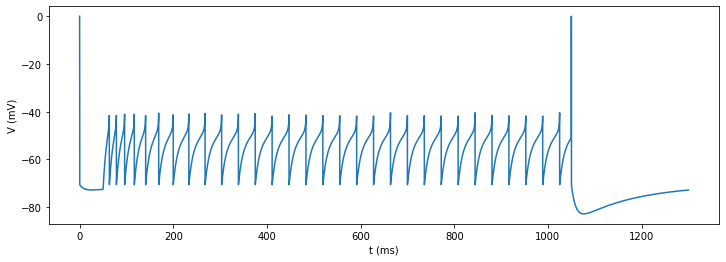

In [ ]:
# Plot the neuron's membrane potential
figure(figsize=(12,4))
plot(mon.t/ms,mon.vm[0]/mV)
ylabel('V (mV)')
xlabel('t (ms)')

### Example: Plot all the state variables in separate subplots, including:
1. Membrane potential trace
2. Refractory variable trace
3. Current injection
4. State space (membrane potential vs refractory variable)

#### Our Solution

{'I0': 0. * amp, 'I1': 1. * namp, 'dv0': 0. * volt, 'T0': 50. * msecond, 'T1': 1. * second, 'T2': 200. * msecond, 'tauw': 144. * msecond, 'a': 4. * nsiemens, 'b': 80.5 * pamp, 'Vr': -70.6 * mvolt, 'I': 1. * namp}


Text(0.5, 0, 'V (mV)')

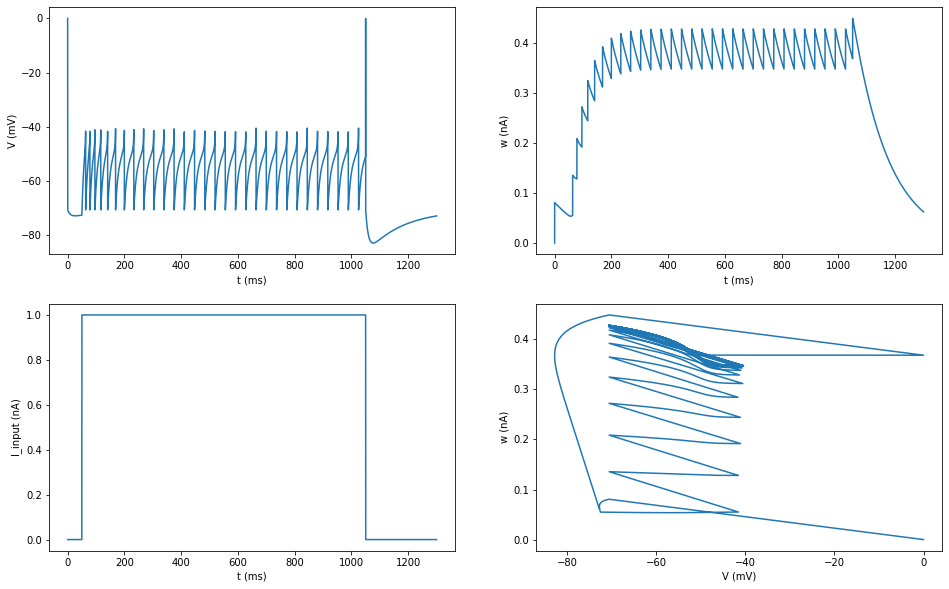

In [ ]:
start_scope()

# general parameters:
C=281*pF # Can be fixed
gL=30*nS
taum=C/gL
EL=-70.6*mV # Same as changing I
VT=-50.4*mV
DeltaT=2*mV
Vcut=VT+5*DeltaT

# set the parameters
namespace_params = set_parameters('regular') #Return parameters, applied current, and inital vm

# create a neuron groupp containing 1 neuron defined by equations above
neuron = NeuronGroup(1,model=state_eqs+input_eqs,threshold=threshold_eq, reset=reset_eqs, namespace=namespace_params, method='euler',name='neuron')

# check the parameters of your differentiated neuron
print(neuron.namespace)

# to retrieve the values of vm of the first neuron, write 'mon_v.vm[0]
mon = StateMonitor(neuron,['vm', 'I_input', 'w'],record=0) 

# the spike monitor records the times of the spikes in the array 'spikes.t'
spikes=SpikeMonitor(neuron)

# Set Initial vm and I accordign to the parameters saved in our 'neuron'
neuron.vm = neuron.namespace['dv0']
neuron.I_input = neuron.namespace['I0']

# initial duration (relaxation)
run(neuron.namespace['T0'])

# apply current and run for duration T1
neuron.I_input = neuron.namespace['I1']
run(neuron.namespace['T1'])

# back to no current and relax
neuron.vm = neuron.namespace['dv0']
neuron.I_input = neuron.namespace['I0']
run(50*ms)

# we run the neuron for T2 seconds
run(neuron.namespace['T2'])

# Plot the neuron's membrane potential
figure(figsize=(16,10))

plt.subplot(2,2,1)
plot(mon.t/ms,mon.vm[0]/mV)
ylabel('V (mV)')
xlabel('t (ms)')

plt.subplot(2,2,2)
plot(mon.t/ms,mon.w[0]/nA)
ylabel('w (nA)')
xlabel('t (ms)')

plt.subplot(2,2,3)
plot(mon.t/ms, mon.I_input[0]/nA)
ylabel('I_input (nA)')
xlabel('t (ms)')

plt.subplot(2,2,4)
plot(mon.vm[0]/mV,mon.w[0]/nA)
ylabel('w (nA)')
xlabel('V (mV)')

# Exercises:


## Exercise 1.
Go back to the line that parameterizes the neuron ```set_parameters(neuron, type)```, choose yourself a neuron type by its name and re-run the simulation. Can you see why the neuron has the name it has? Bonus: Attempt to relate the parameters with the behavior the neuron model displays.

## Exercise 2. 

Create F x I curves for the following neuronal types: **regular**, and **bursting tonic**. Display the FxI curves in the same axes and add legends. Determine which of them is of "Type I" and which one is "Type II" (http://www.scholarpedia.org/article/Adaptive_exponential_integrate-and-fire_model#Type_I_and_Type_II_in_frequency-current_curves).

The idea is that you select a range for input currents (say from 0*nA to 1.5*nA, in 40 steps)

You can check how to calculate and display F x I curves at https://brian2.readthedocs.io/en/stable/examples/IF_curve_LIF.html

Brain's way to do it is to **sweep over the parameter space** of currents (I)via a group of unconnected neurons, where each is given a current pulse of increasing amplitude. 

Note: To compute the firing rate, be sure to only take the spikes that are due to the period of stimulation.

#### Your Code

In [ ]:
start_scope()

# general parameters:
C=281*pF # Can be fixed
gL=30*nS
taum=C/gL
EL=-70.6*mV # Same as changing I
VT=-50.4*mV
DeltaT=2*mV
Vcut=VT+5*DeltaT

# set the parameters
namespace_params = set_parameters('fast') #Return parameters, applied current, and inital vm

# create a neuron groupp containing 1 neuron defined by equations above
neuron = NeuronGroup(1,model=state_eqs+input_eqs,threshold=threshold_eq, reset=reset_eqs, namespace=namespace_params, method='euler',name='neuron')

# check the parameters of your differentiated neuron
print(neuron.namespace)

# to retrieve the values of vm of the first neuron, write 'mon_v.vm[0]
mon = StateMonitor(neuron,['vm', 'I_input', 'w'],record=0) 

# the spike monitor records the times of the spikes in the array 'spikes.t'
spikes=SpikeMonitor(neuron)

# Set Initial vm and I accordign to the parameters saved in our 'neuron'
neuron.vm = neuron.namespace['dv0']
neuron.I_input = neuron.namespace['I0']

# initial duration (relaxation)
run(neuron.namespace['T0'])

# apply current and run for duration T1
neuron.I_input = neuron.namespace['I1']
run(neuron.namespace['T1'])

# back to no current and relax
neuron.vm = neuron.namespace['dv0']
neuron.I_input = neuron.namespace['I0']
run(50*ms)

# we run the neuron for T2 seconds
run(neuron.namespace['T2'])

# Plot the neuron's membrane potential
figure(figsize=(12,4))
plot(mon.t/ms,mon.vm[0]/mV)
ylabel('V (mV)')
xlabel('t (ms)')